# Week 3: Data Normalization, Unsupervised Learning, Confusion matrix

## Learning Objectives

1. Apply z-score normalization and understand why it is necessary before PCA and clustering
2. Perform PCA for dimensionality reduction and interpret loadings, scores, and cumulative explained variance
3. Apply K-Means clustering and select K using the elbow method and silhouette scores
4. Apply hierarchical clustering, read a dendrogram, and compare different linkage methods
5. Evaluate unsupervised results against known labels using a confusion matrix

In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv('heart_failure_clinical_records_dataset.csv')
df.drop(columns=['time'], inplace=True)
df_features = df.iloc[:, :-1]
df_target = df['DEATH_EVENT']

## Data Normalization 

$$z = \frac{x - \mu}{\sigma}$$

z: zscore

$\mu$: average value 

$\sigma$: standard deviation 

In [2]:
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

df_features_zscored = stats.zscore(df_features)

df_features_zscored

array([[ 1.19294523e+00, -8.71104775e-01,  1.65728387e-04, ...,
        -1.50403612e+00,  7.35688190e-01, -6.87681906e-01],
       [-4.91279276e-01, -8.71104775e-01,  7.51463953e+00, ...,
        -1.41976151e-01,  7.35688190e-01, -6.87681906e-01],
       [ 3.50832977e-01, -8.71104775e-01, -4.49938761e-01, ...,
        -1.73104612e+00,  7.35688190e-01,  1.45416070e+00],
       ...,
       [-1.33339153e+00, -8.71104775e-01,  1.52597865e+00, ...,
         3.12043840e-01, -1.35927151e+00, -6.87681906e-01],
       [-1.33339153e+00, -8.71104775e-01,  1.89039811e+00, ...,
         7.66063830e-01,  7.35688190e-01,  1.45416070e+00],
       [-9.12335403e-01, -8.71104775e-01, -3.98321274e-01, ...,
        -1.41976151e-01,  7.35688190e-01,  1.45416070e+00]],
      shape=(299, 11))

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [Text(0, 0, '0'),
  Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10')])

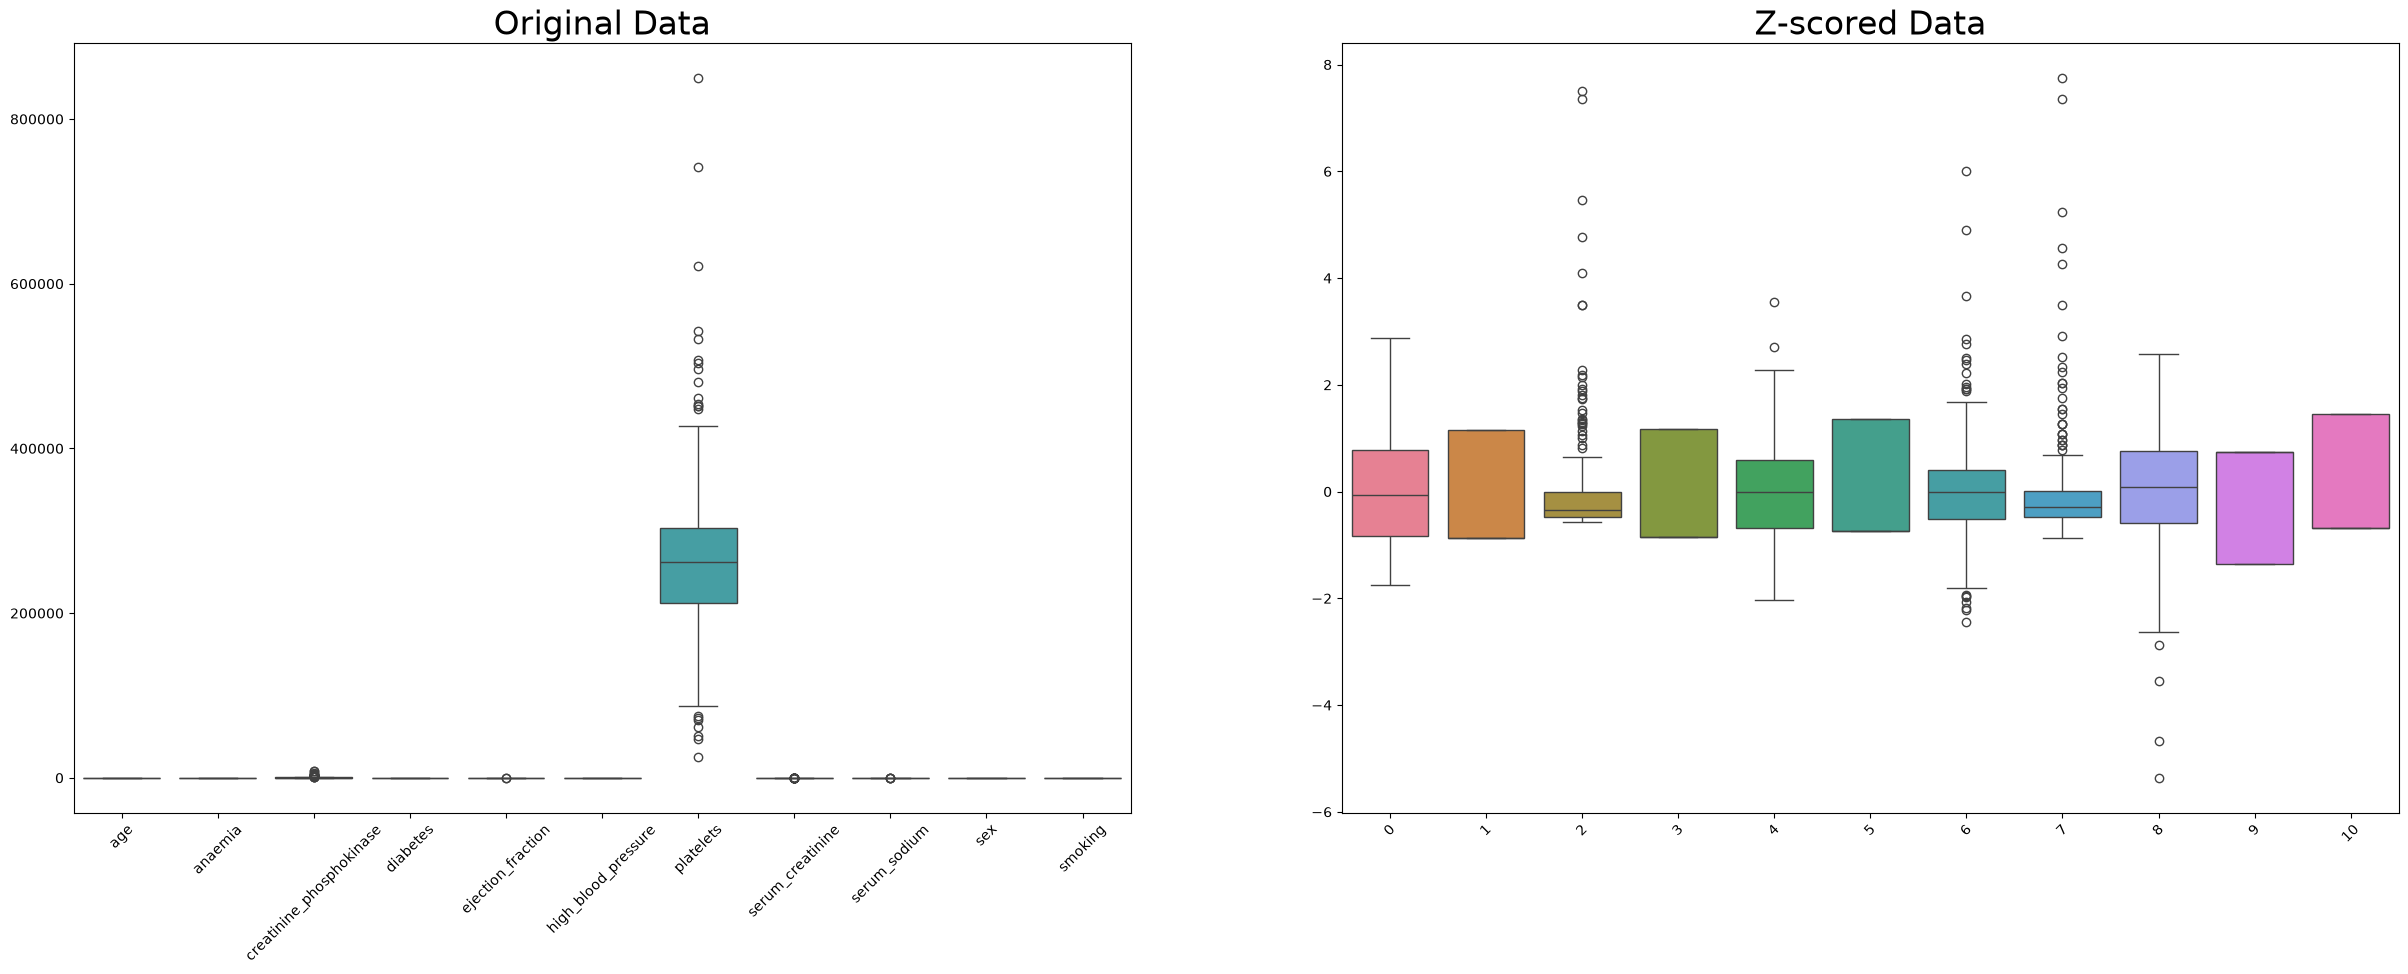

In [3]:
plt.figure(figsize=(30, 10))
plt.subplot(1, 2, 1)
sns.boxplot(df_features)
plt.title('Original Data', size=24)
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.boxplot(df_features_zscored)
plt.title('Z-scored Data', size=24)
plt.xticks(rotation=45)

## Principal Component Analysis (PCA)

$$X \sim Z.W^T$$

X: Original data

$Z.W^T$: Reconstructed data

Goal: Find a W (projection matrix) that minimizes the error between X and $Z.W^T$

In [4]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
pca = pca.fit(df_features_zscored)
y = pca.fit_transform(df_features_zscored)
loadings = pca.components_.T

In [5]:
pca.explained_variance_

array([1.66854527, 1.40009634, 1.27097518])

In [6]:
pca.explained_variance_ratio_

array([0.15117862, 0.12685579, 0.11515677])

In [7]:
pca.components_.shape

(3, 11)

In [8]:
pca.n_components_

3

In [9]:
y.shape

(299, 3)

## loadings value: How strongly each feature contributes to each principal component

In [10]:
loadings.shape

(11, 3)

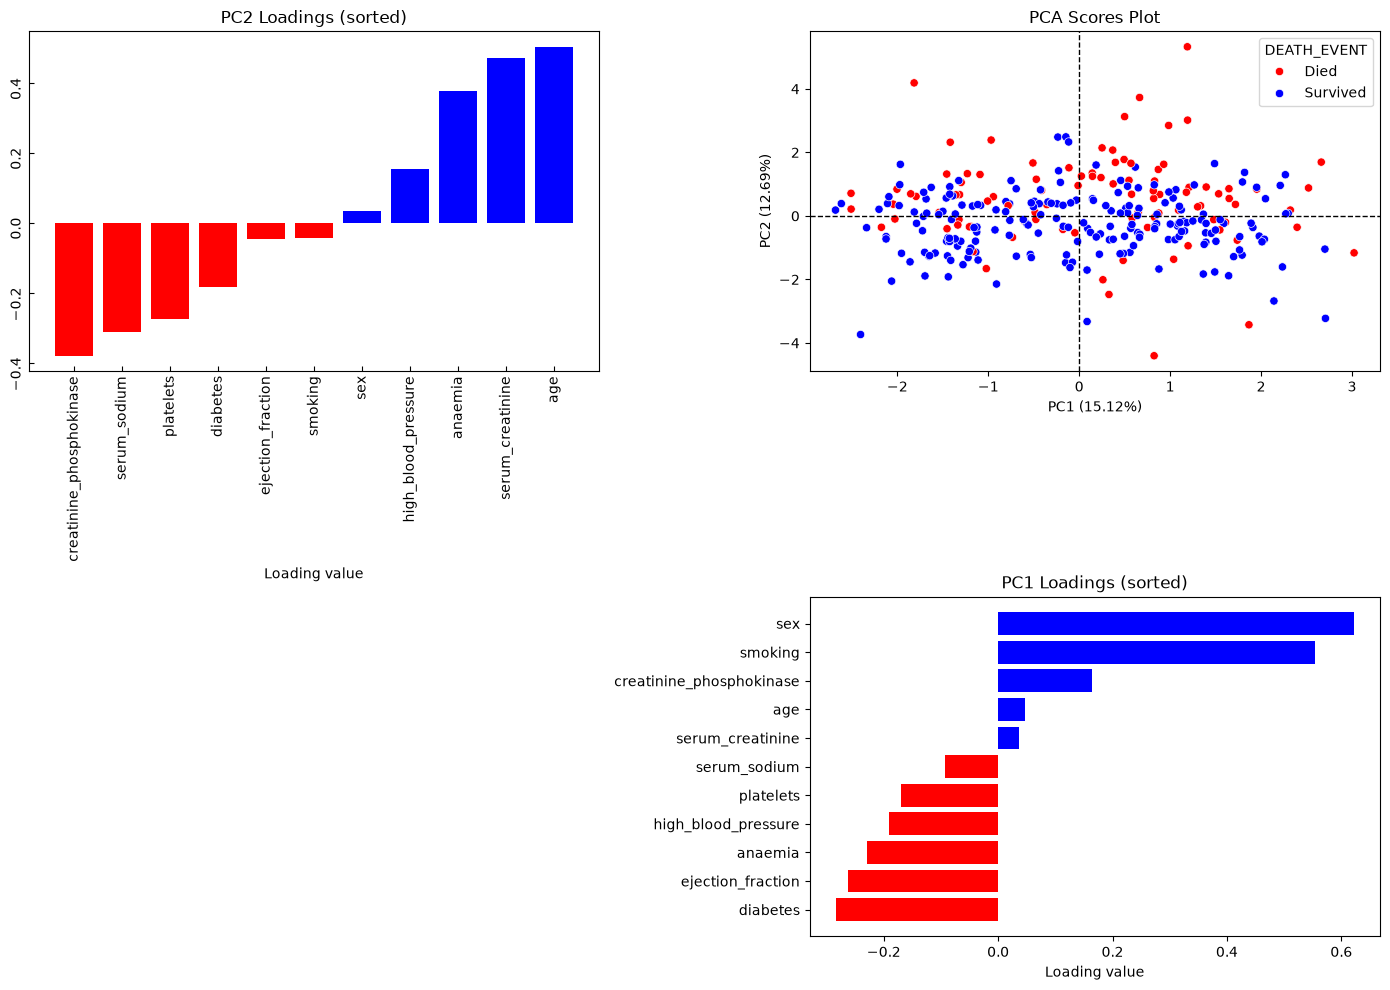

In [11]:
feature_names = df_features.columns

pc1_loadings = pd.Series(loadings[:, 0], index=feature_names).sort_values()
pc2_loadings = pd.Series(loadings[:, 1], index=feature_names).sort_values()

pc1_colors = ['red' if v < 0 else 'blue' for v in pc1_loadings]
pc2_colors = ['red' if v < 0 else 'blue' for v in pc2_loadings]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].bar(pc2_loadings.index, pc2_loadings.values, color=pc2_colors)
axes[0, 0].set_title('PC2 Loadings (sorted)')
axes[0, 0].set_xlabel('Loading value')
axes[0, 0].tick_params(axis='both', direction='in', rotation=90)

color_mapping = {'Died': 'r', 'Survived': 'b'}
sns.scatterplot(x=y[:, 0], y=y[:, 1], hue=df_target.map({1: 'Died', 0: 'Survived'}), ax=axes[0, 1], palette=color_mapping)
axes[0, 1].axhline(0, linestyle='--', linewidth=1, color='black')
axes[0, 1].axvline(0, linestyle='--', linewidth=1, color='black')
axes[0, 1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
axes[0, 1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
axes[0, 1].set_title('PCA Scores Plot')

axes[1,1].barh(pc1_loadings.index, pc1_loadings.values, color=pc1_colors)
axes[1,1].set_title('PC1 Loadings (sorted)')
axes[1,1].set_xlabel('Loading value')

axes[1,0].axis('off')

plt.tight_layout()
plt.show()

## Exercise: Run PCA on non-normalized data. What do you see and why it happens?

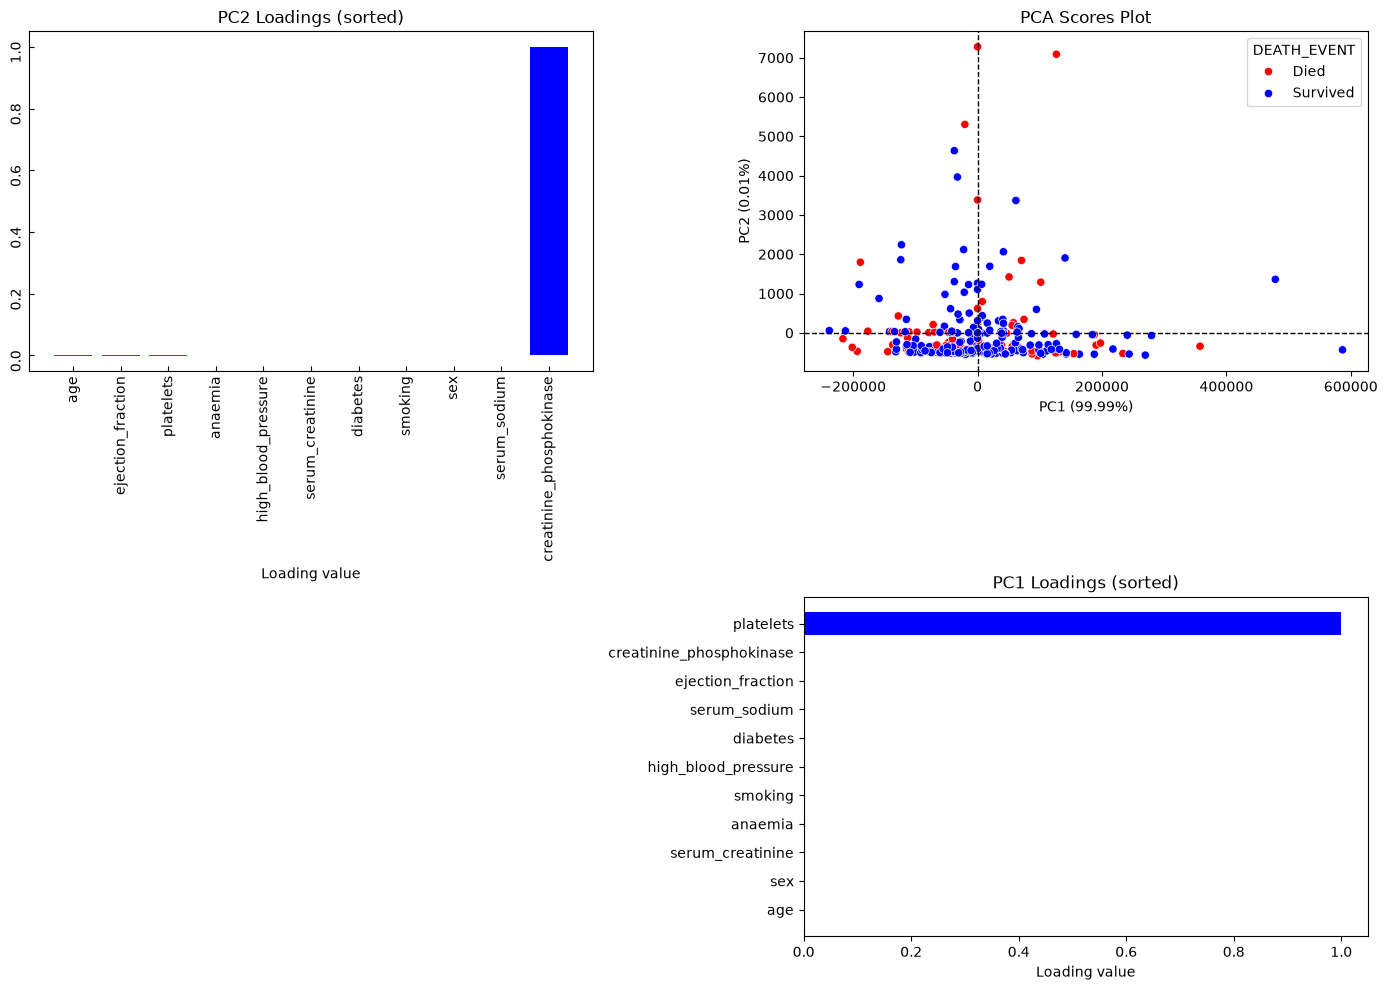

In [12]:
pca = PCA(n_components=3)
pca = pca.fit(df_features)
y = pca.fit_transform(df_features)
loadings = pca.components_.T
feature_names = df_features.columns

pc1_loadings = pd.Series(loadings[:, 0], index=feature_names).sort_values()
pc2_loadings = pd.Series(loadings[:, 1], index=feature_names).sort_values()

pc1_colors = ['red' if v < 0 else 'blue' for v in pc1_loadings]
pc2_colors = ['red' if v < 0 else 'blue' for v in pc2_loadings]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].bar(pc2_loadings.index, pc2_loadings.values, color=pc2_colors)
axes[0, 0].set_title('PC2 Loadings (sorted)')
axes[0, 0].set_xlabel('Loading value')
axes[0, 0].tick_params(axis='both', direction='in', rotation=90)

color_mapping = {'Died': 'r', 'Survived': 'b'}
sns.scatterplot(x=y[:, 0], y=y[:, 1], hue=df_target.map({1: 'Died', 0: 'Survived'}), ax=axes[0, 1], palette=color_mapping)
axes[0, 1].axhline(0, linestyle='--', linewidth=1, color='black')
axes[0, 1].axvline(0, linestyle='--', linewidth=1, color='black')
axes[0, 1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)")
axes[0, 1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)")
axes[0, 1].set_title('PCA Scores Plot')

axes[1, 1].barh(pc1_loadings.index, pc1_loadings.values, color=pc1_colors)
axes[1, 1].set_title('PC1 Loadings (sorted)')
axes[1, 1].set_xlabel('Loading value')

axes[1, 0].axis('off')

plt.tight_layout()
plt.show()

## Exercise: Run PCA on normalized data but this time exclude the 'time' column. 

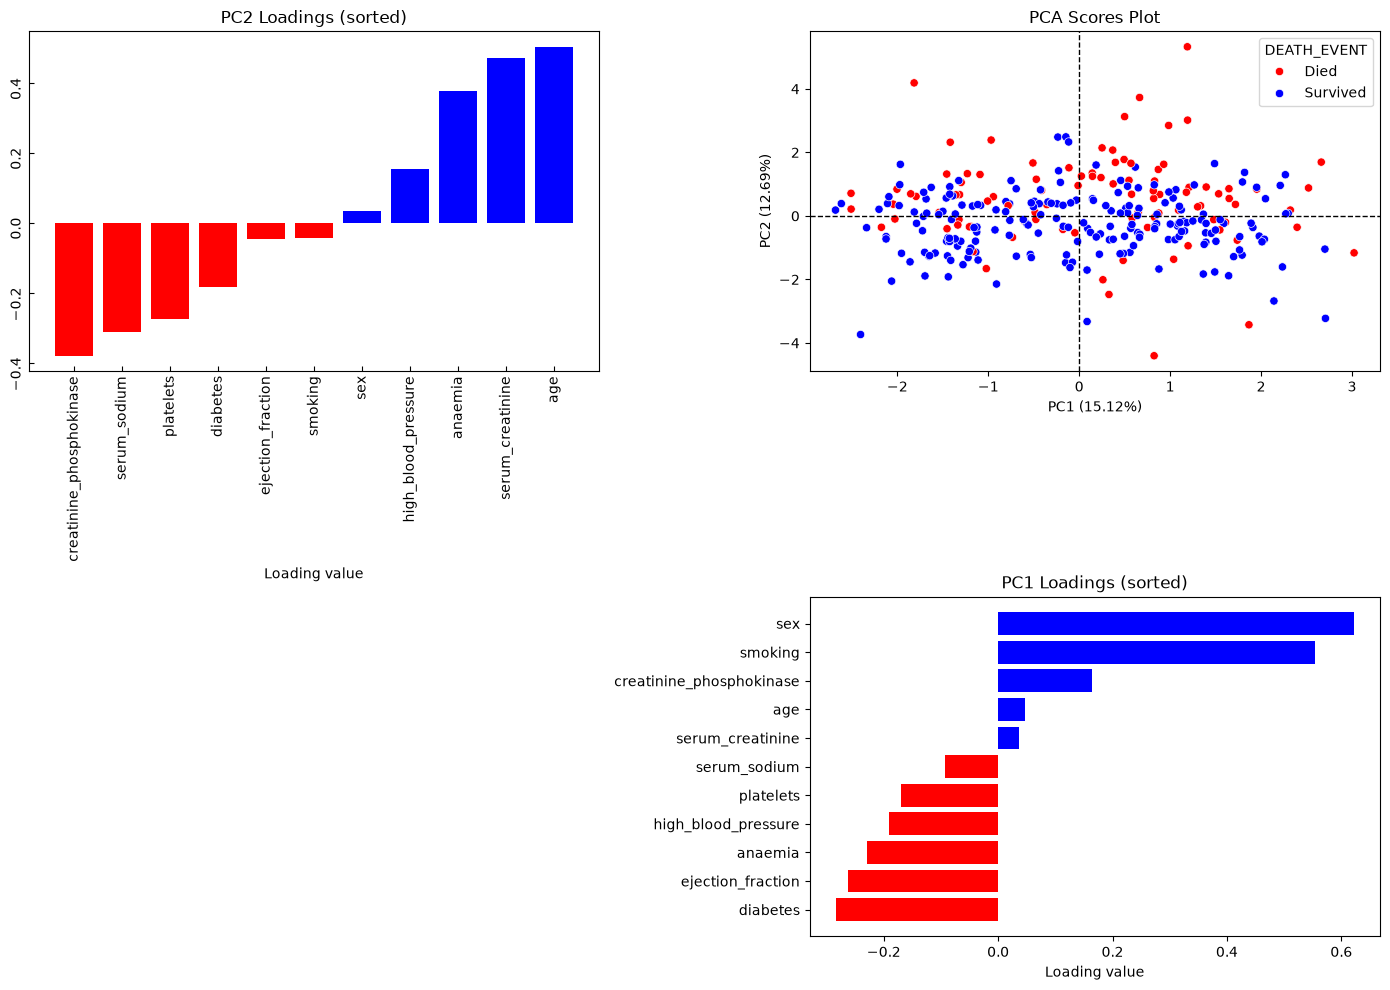

In [13]:
pca = PCA(n_components=3)
pca = pca.fit(df_features_zscored)
y = pca.fit_transform(df_features_zscored)
loadings = pca.components_.T
feature_names = df_features.columns

pc1_loadings = pd.Series(loadings[:, 0], index=feature_names).sort_values()
pc2_loadings = pd.Series(loadings[:, 1], index=feature_names).sort_values()

pc1_colors = ['red' if v < 0 else 'blue' for v in pc1_loadings]
pc2_colors = ['red' if v < 0 else 'blue' for v in pc2_loadings]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].bar(pc2_loadings.index, pc2_loadings.values, color=pc2_colors)
axes[0, 0].set_title('PC2 Loadings (sorted)')
axes[0, 0].set_xlabel('Loading value')
axes[0, 0].tick_params(axis='both', direction='in', rotation=90)

color_mapping = {'Died': 'r', 'Survived': 'b'}
sns.scatterplot(x=y[:, 0], y=y[:, 1], hue=df_target.map({1: 'Died', 0: 'Survived'}), ax=axes[0, 1], palette=color_mapping)
axes[0, 1].axhline(0, linestyle='--', linewidth=1, color='black')
axes[0, 1].axvline(0, linestyle='--', linewidth=1, color='black')
axes[0, 1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)")
axes[0, 1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)")
axes[0, 1].set_title('PCA Scores Plot')

axes[1, 1].barh(pc1_loadings.index, pc1_loadings.values, color=pc1_colors)
axes[1, 1].set_title('PC1 Loadings (sorted)')
axes[1, 1].set_xlabel('Loading value')

axes[1, 0].axis('off')

plt.tight_layout()
plt.show()

## Cumulative Explained Variance (Scree Plot)

How many principal components do we need to capture most of the information in the data?

A common rule of thumb is to keep enough components to explain **~80-90%** of the total variance.

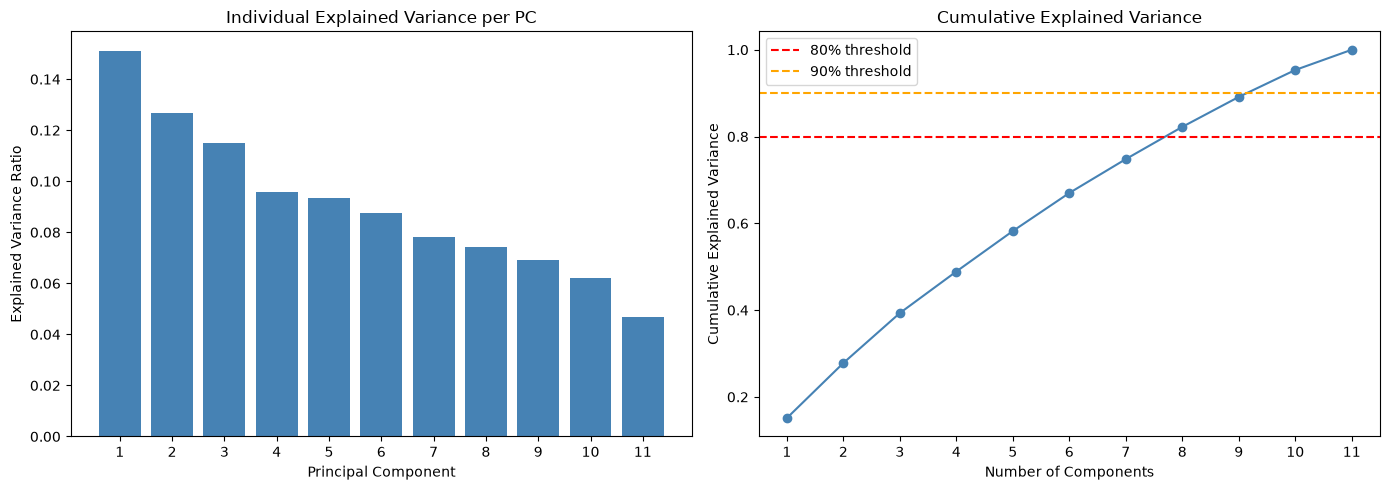

Components needed for 80% variance: 8
Components needed for 90% variance: 10


In [14]:
import numpy as np

pca_full = PCA().fit(df_features_zscored)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
            pca_full.explained_variance_ratio_, color='steelblue')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Individual Explained Variance per PC')
axes[0].set_xticks(range(1, len(pca_full.explained_variance_ratio_) + 1))

axes[1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'o-', color='steelblue')
axes[1].axhline(y=0.8, color='red', linestyle='--', label='80% threshold')
axes[1].axhline(y=0.9, color='orange', linestyle='--', label='90% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xticks(range(1, len(cumulative_variance) + 1))
axes[1].legend()

plt.tight_layout()
plt.show()

for threshold in [0.8, 0.9]:
    n_components = np.argmax(cumulative_variance >= threshold) + 1
    print(f"Components needed for {threshold:.0%} variance: {n_components}")

## Discussion: If you run PCA on non-normalized data, PC1 explains ~90% of the variance by itself. Is this a good thing? Why or why not?

## K-Means Clustering

Now that we can visualize the data in lower dimensions with PCA, let's see if unsupervised clustering can recover the survived/died groups without using the labels.

In [15]:
from sklearn.cluster import KMeans

df_features_normalized = stats.zscore(df_features)
df_features_normalized = pd.DataFrame(df_features_normalized, columns=df_features.columns)

kmeans = KMeans(n_clusters=2, random_state=42, n_init='auto')
clusters = kmeans.fit_predict(df_features_normalized)

df_features_normalized['cluster'] = clusters
df_features_normalized

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,cluster
0,1.192945,-0.871105,0.000166,-0.847579,-1.530560,1.359272,1.681648e-02,0.490057,-1.504036,0.735688,-0.687682,0
1,-0.491279,-0.871105,7.514640,-0.847579,-0.007077,-0.735688,7.535660e-09,-0.284552,-0.141976,0.735688,-0.687682,0
2,0.350833,-0.871105,-0.449939,-0.847579,-1.530560,-0.735688,-1.038073e+00,-0.090900,-1.731046,0.735688,1.454161,0
3,-0.912335,1.147968,-0.486071,-0.847579,-1.530560,-0.735688,-5.464741e-01,0.490057,0.085034,0.735688,-0.687682,0
4,0.350833,1.147968,-0.435486,1.179830,-1.530560,-0.735688,6.517986e-01,1.264666,-4.682176,-1.359272,-0.687682,1
...,...,...,...,...,...,...,...,...,...,...,...,...
294,0.098199,-0.871105,-0.537688,1.179830,-0.007077,1.359272,-1.109765e+00,-0.284552,1.447094,0.735688,1.454161,0
295,-0.491279,-0.871105,1.278215,-0.847579,-0.007077,-0.735688,6.802472e-02,-0.187726,0.539054,-1.359272,-0.687682,1
296,-1.333392,-0.871105,1.525979,1.179830,1.854958,-0.735688,4.902082e+00,-0.575031,0.312044,-1.359272,-0.687682,1
297,-1.333392,-0.871105,1.890398,-0.847579,-0.007077,-0.735688,-1.263389e+00,0.005926,0.766064,0.735688,1.454161,0


/Users/namvu/Desktop/UMich/MDST/heart-failure-survival-analysis/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


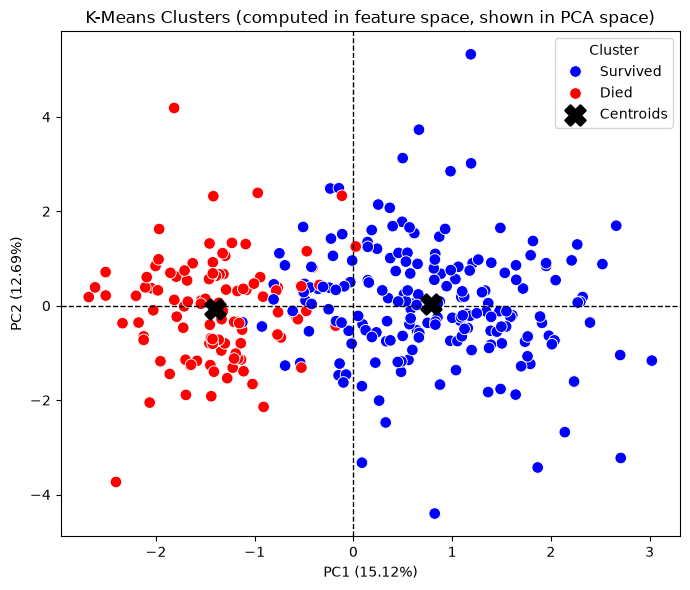

In [16]:
pca = PCA(n_components=3)
pca = pca.fit(df_features_normalized.iloc[:, :-1])
y = pca.fit_transform(df_features_normalized.iloc[:, :-1])

plt.figure(figsize=(7, 6))

color_mapping = {'Died': 'r', 'Survived': 'b'}
sns.scatterplot(
    x=y[:, 0],
    y=y[:, 1],
    hue=df_features_normalized['cluster'].map({1: 'Died', 0: 'Survived'}),
    palette=color_mapping,
    s=70,
)

# transform cluster centers into PCA space
centers_pca = pca.transform(kmeans.cluster_centers_)

plt.scatter(centers_pca[:, 0], centers_pca[:, 1], marker='X', s=200, linewidth=2, color='black', label='Centroids')

plt.axhline(0, linestyle='--', linewidth=1, color='black')
plt.axvline(0, linestyle='--', linewidth=1, color='black')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.title('K-Means Clusters (computed in feature space, shown in PCA space)')
plt.legend(title='Cluster')

plt.tight_layout()
plt.show()

[Text(0, 0.5, 'Survived'), Text(0, 1.5, 'Died')]

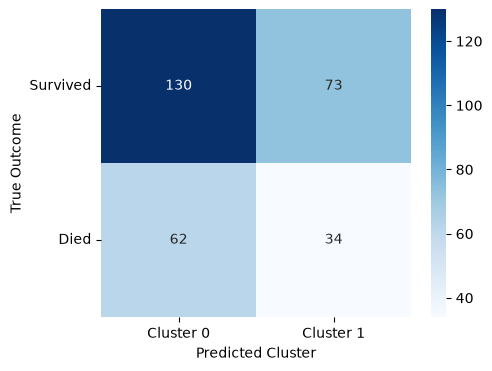

In [17]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(df_target, clusters)

plt.figure(figsize=(5, 4))

ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
ax.set_xlabel('Predicted Cluster')
ax.set_ylabel('True Outcome')
ax.set_xticklabels(['Cluster 0', 'Cluster 1'])
ax.set_yticklabels(['Survived', 'Died'], rotation=0)

## How to identify the optimal number of K?

$$\text{Silhouette score} = \frac{b-a}{max(a,b)}$$

For each datapoint: 
- a: distance to points in the same cluster
- b: distance to points in other clusters
- Silhouette score = 1 → Perfect clustering
- Silhouette score < 0.25 → Weak clustering 

In [18]:
df_features_normalized

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,cluster
0,1.192945,-0.871105,0.000166,-0.847579,-1.530560,1.359272,1.681648e-02,0.490057,-1.504036,0.735688,-0.687682,0
1,-0.491279,-0.871105,7.514640,-0.847579,-0.007077,-0.735688,7.535660e-09,-0.284552,-0.141976,0.735688,-0.687682,0
2,0.350833,-0.871105,-0.449939,-0.847579,-1.530560,-0.735688,-1.038073e+00,-0.090900,-1.731046,0.735688,1.454161,0
3,-0.912335,1.147968,-0.486071,-0.847579,-1.530560,-0.735688,-5.464741e-01,0.490057,0.085034,0.735688,-0.687682,0
4,0.350833,1.147968,-0.435486,1.179830,-1.530560,-0.735688,6.517986e-01,1.264666,-4.682176,-1.359272,-0.687682,1
...,...,...,...,...,...,...,...,...,...,...,...,...
294,0.098199,-0.871105,-0.537688,1.179830,-0.007077,1.359272,-1.109765e+00,-0.284552,1.447094,0.735688,1.454161,0
295,-0.491279,-0.871105,1.278215,-0.847579,-0.007077,-0.735688,6.802472e-02,-0.187726,0.539054,-1.359272,-0.687682,1
296,-1.333392,-0.871105,1.525979,1.179830,1.854958,-0.735688,4.902082e+00,-0.575031,0.312044,-1.359272,-0.687682,1
297,-1.333392,-0.871105,1.890398,-0.847579,-0.007077,-0.735688,-1.263389e+00,0.005926,0.766064,0.735688,1.454161,0


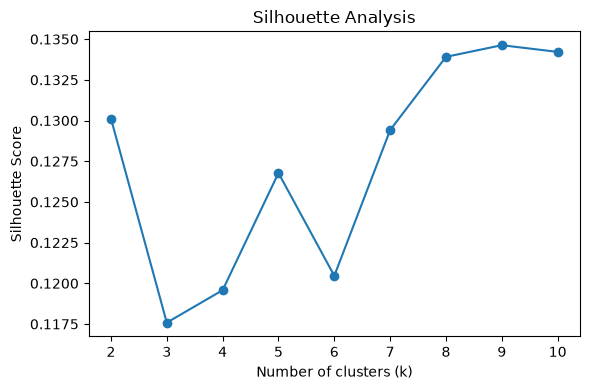

In [19]:
from sklearn.metrics import silhouette_score

inertia = []
sil_scores = []
K = range(2, 11) # silhouette requires at least 2 clusters

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(df_features_normalized.iloc[:, :-1])

    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(df_features_normalized.iloc[:, :-1], labels))

plt.figure(figsize=(6, 4))
plt.plot(K, sil_scores, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')

plt.tight_layout()
plt.show()

## Elbow Method

The elbow method plots the inertia (within-cluster sum of squares) against the number of clusters K:

$$\text{Inertia} = \sum_{i=1}^{n} \| x_i - c_{k} \|^2$$

- $c_k$: Centroid of the cluster that point $x_i$ belongs to
- As K increases, inertia always decreases (more clusters = points closer to centroids)
- The elbow is where adding more clusters gives diminishing returns (the curve bends)
- Pick the K at the elbow of the curve

In [20]:
df_features_normalized.drop(columns=['cluster'], inplace=True)
df_features_normalized

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking
0,1.192945,-0.871105,0.000166,-0.847579,-1.530560,1.359272,1.681648e-02,0.490057,-1.504036,0.735688,-0.687682
1,-0.491279,-0.871105,7.514640,-0.847579,-0.007077,-0.735688,7.535660e-09,-0.284552,-0.141976,0.735688,-0.687682
2,0.350833,-0.871105,-0.449939,-0.847579,-1.530560,-0.735688,-1.038073e+00,-0.090900,-1.731046,0.735688,1.454161
3,-0.912335,1.147968,-0.486071,-0.847579,-1.530560,-0.735688,-5.464741e-01,0.490057,0.085034,0.735688,-0.687682
4,0.350833,1.147968,-0.435486,1.179830,-1.530560,-0.735688,6.517986e-01,1.264666,-4.682176,-1.359272,-0.687682
...,...,...,...,...,...,...,...,...,...,...,...
294,0.098199,-0.871105,-0.537688,1.179830,-0.007077,1.359272,-1.109765e+00,-0.284552,1.447094,0.735688,1.454161
295,-0.491279,-0.871105,1.278215,-0.847579,-0.007077,-0.735688,6.802472e-02,-0.187726,0.539054,-1.359272,-0.687682
296,-1.333392,-0.871105,1.525979,1.179830,1.854958,-0.735688,4.902082e+00,-0.575031,0.312044,-1.359272,-0.687682
297,-1.333392,-0.871105,1.890398,-0.847579,-0.007077,-0.735688,-1.263389e+00,0.005926,0.766064,0.735688,1.454161


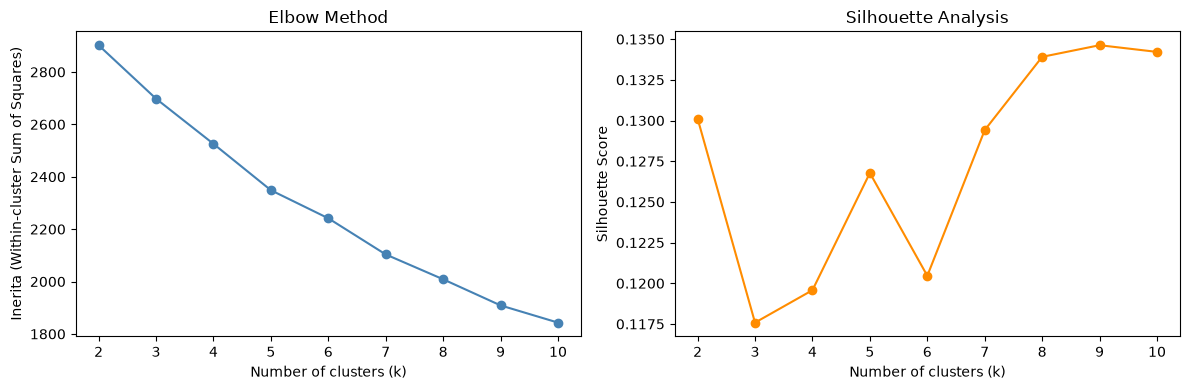

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Elbow plot using inertia values computed above
axes[0].plot(K, inertia, marker='o', color='steelblue')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inerita (Within-cluster Sum of Squares)')
axes[0].set_title('Elbow Method')

# Silhouette plot
axes[1].plot(K, sil_scores, marker='o', color='darkorange')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Analysis')

plt.tight_layout()
plt.show()

## Exercise: K-Means with another K value, scatter on top 2 features (one on x-axis and another on y-axis, color them based on cluster label)

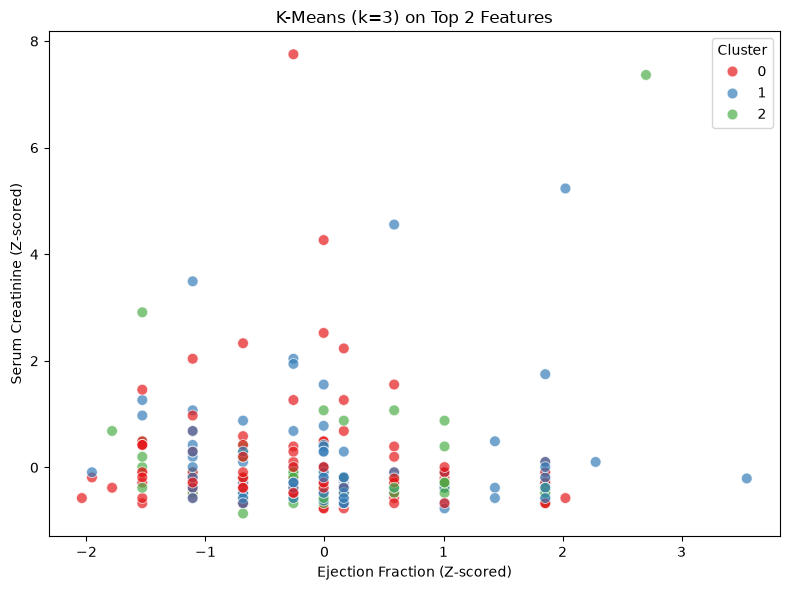

In [22]:
km3 = KMeans(n_clusters=3, random_state=42, n_init='auto')
clusters_k3 = km3.fit_predict(df_features_normalized)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=df_features_normalized['ejection_fraction'],
    y=df_features_normalized['serum_creatinine'],
    hue=clusters_k3,
    palette='Set1',
    s=60, alpha=0.7
)
plt.xlabel('Ejection Fraction (Z-scored)')
plt.ylabel('Serum Creatinine (Z-scored)')
plt.title('K-Means (k=3) on Top 2 Features')
plt.legend(title='Cluster')

plt.tight_layout()
plt.show()

## Exercise: K-Means k=2, real labels vs cluster labels side-by-side

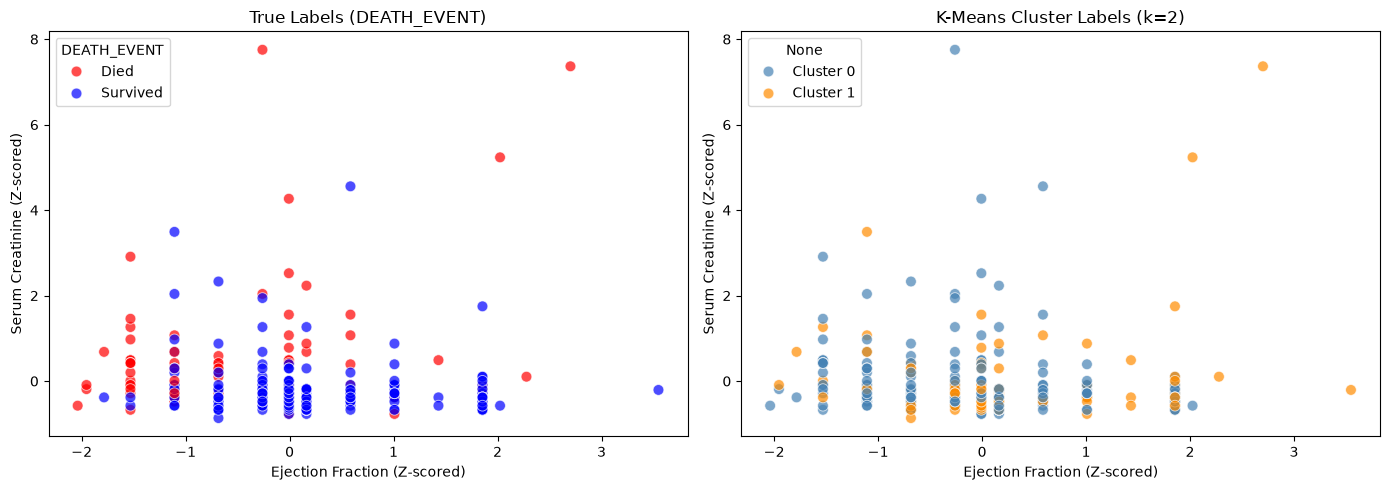

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

color_mapping = {'Died': 'r', 'Survived': 'b'}
sns.scatterplot(
    x=df_features_normalized['ejection_fraction'],
    y=df_features_normalized['serum_creatinine'],
    hue=df_target.map({1: 'Died', 0: 'Survived'}),
    palette=color_mapping, ax=axes[0], s=60, alpha=0.7
)
axes[0].set_title('True Labels (DEATH_EVENT)')
axes[0].set_xlabel('Ejection Fraction (Z-scored)')
axes[0].set_ylabel('Serum Creatinine (Z-scored)')

sns.scatterplot(
    x=df_features_normalized['ejection_fraction'],
    y=df_features_normalized['serum_creatinine'],
    hue=pd.Series(clusters).map({0: 'Cluster 0', 1: 'Cluster 1'}),
    palette={'Cluster 0': 'steelblue', 'Cluster 1': 'darkorange'},
    ax=axes[1], s=60, alpha=0.7
)
axes[1].set_title('K-Means Cluster Labels (k=2)')
axes[1].set_xlabel('Ejection Fraction (Z-scored)')
axes[1].set_ylabel('Serum Creatinine (Z-scored)')

plt.tight_layout()
plt.show()

## Hierarchical (Agglomerative) Clustering

Key differences from K-Means:
- Bottom-up approach: Start with each point as its own cluster, then merge the closest pairs
- Not require specifying K upfront (you can decide after seeing the dendrogram)
- Produce a tree structure (dendrogram) showing how clusters merge at different distance thresholds

Linkage methods (how to measure distance between clusters):
- `ward`: Minimize the total within-cluster variance (default, tend to produce balanced clusters)
- `complete`: Max distance between any two points in the two clusters
- `average`: Average distance between all pairs of points across the two clusters
- `single`: Min distance between any two points (can produce elongated chains)

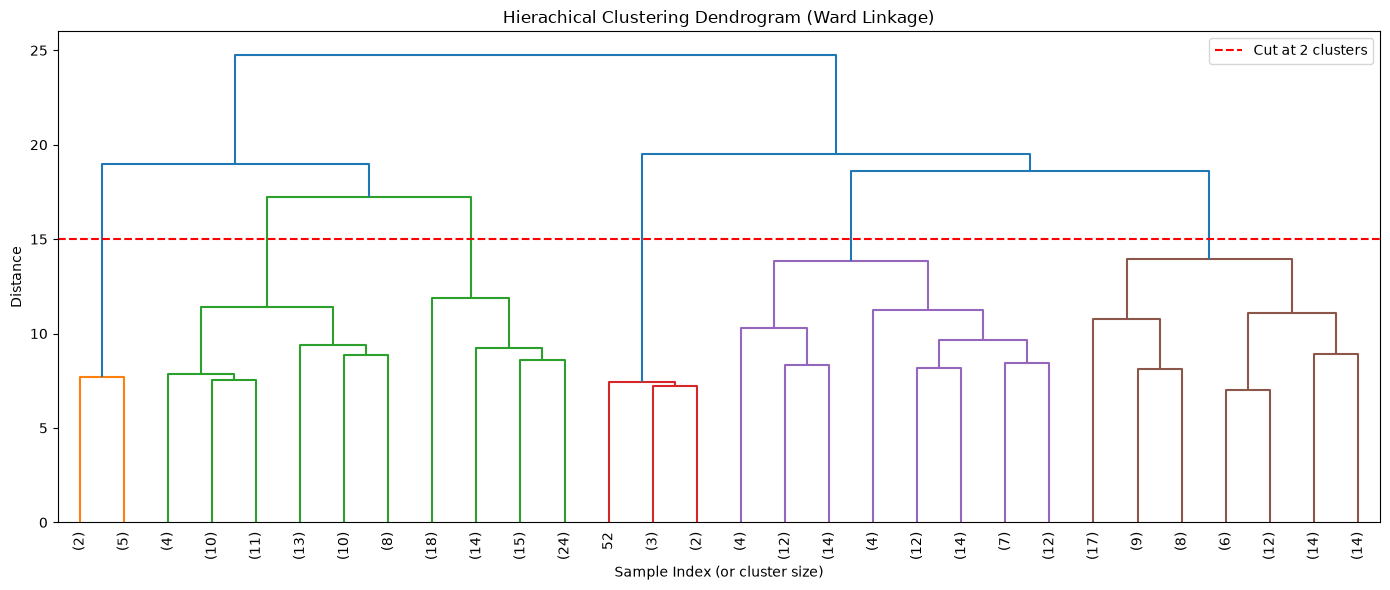

In [24]:
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(df_features_normalized, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=10)

plt.title('Hierachical Clustering Dendrogram (Ward Linkage)')
plt.xlabel('Sample Index (or cluster size)')
plt.ylabel('Distance')
plt.axhline(y=15, color='red', linestyle='--', label='Cut at 2 clusters')
plt.legend()

plt.tight_layout()
plt.show()

In [25]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=2, linkage='ward')
hc_labels = agg.fit_predict(df_features_normalized)

print(f"Cluster 0: {sum(hc_labels == 0)} points")
print(f"Cluster 1: {sum(hc_labels == 1)} points")

Cluster 0: 165 points
Cluster 1: 134 points


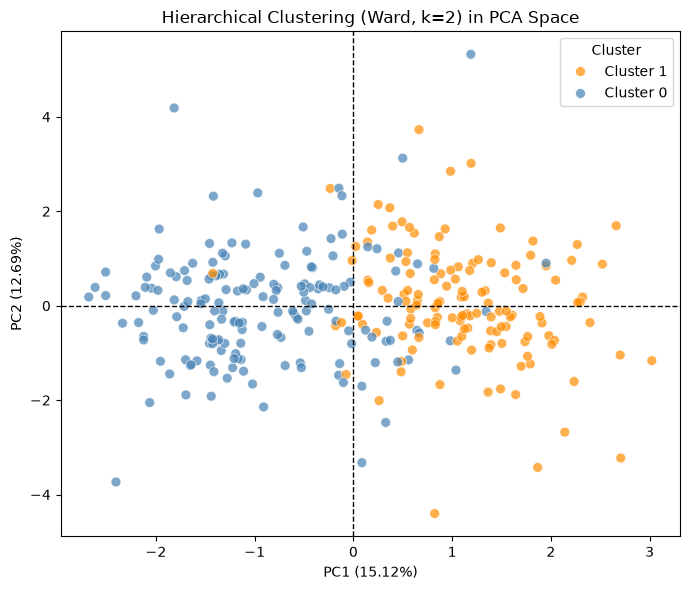

In [26]:
pca_hc = PCA(n_components=2).fit(df_features_normalized)
y_hc = pca_hc.transform(df_features_normalized)

plt.figure(figsize=(7, 6))
sns.scatterplot(
    x=y_hc[:, 0], y=y_hc[:, 1],
    hue=pd.Series(hc_labels).map({0: 'Cluster 0', 1: 'Cluster 1'}),
    palette={'Cluster 0': 'steelblue', 'Cluster 1': 'darkorange'},
    s=50, alpha=0.7
)

plt.axhline(0, linestyle='--', linewidth=1, color='black')
plt.axvline(0, linestyle='--', linewidth=1, color='black')
plt.xlabel(f'PC1 ({pca_hc.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'PC2 ({pca_hc.explained_variance_ratio_[1]*100:.2f}%)')
plt.title('Hierarchical Clustering (Ward, k=2) in PCA Space')
plt.legend(title='Cluster')

plt.tight_layout()
plt.show()

## K-Means vs Hierarchical Clustering Comparison

Let's visualize both clustering results side by side, along with the true labels, to see how each method groups the data.

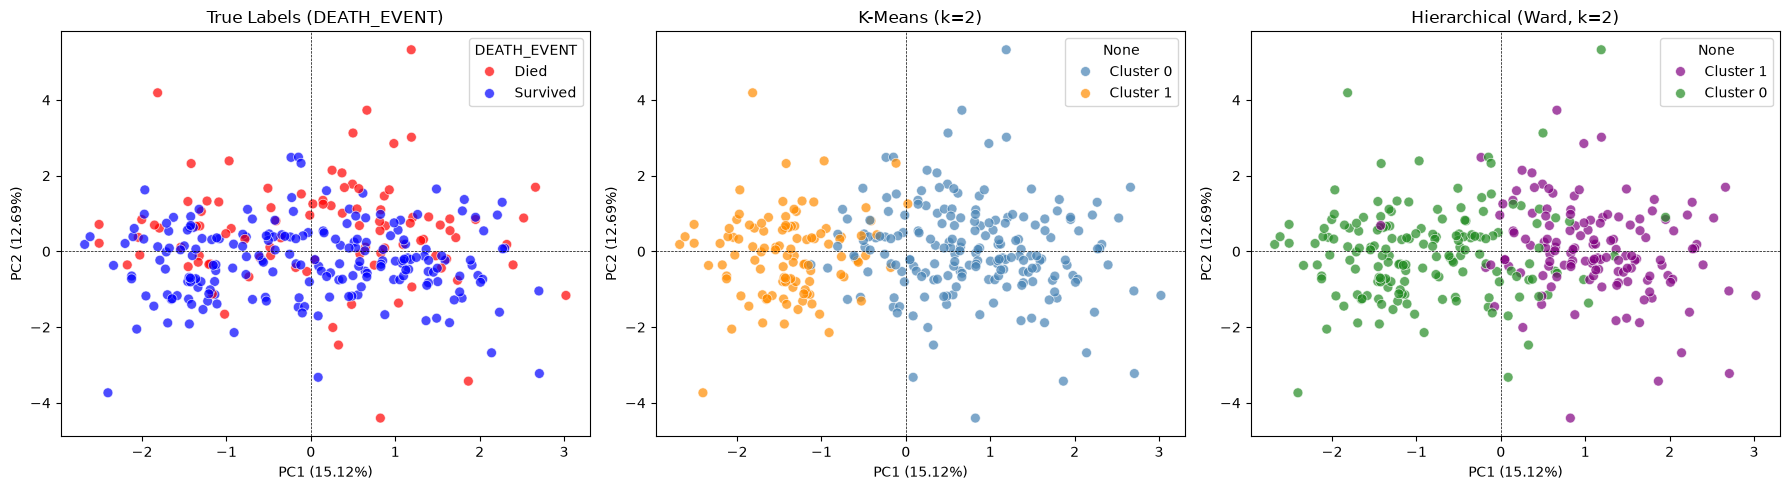

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

color_mapping = {'Died': 'r', 'Survived': 'b'}
sns.scatterplot(
    x=y_hc[:, 0],
    y=y_hc[:, 1],
    hue=df_target.map({1: 'Died', 0: 'Survived'}),
    palette=color_mapping, ax=axes[0], s=50, alpha=0.7
)
axes[0].set_title('True Labels (DEATH_EVENT)')
axes[0].set_xlabel(f'PC1 ({pca_hc.explained_variance_ratio_[0]*100:.2f}%)')
axes[0].set_ylabel(f'PC2 ({pca_hc.explained_variance_ratio_[1]*100:.2f}%)')

sns.scatterplot(
    x=y_hc[:, 0],
    y=y_hc[:, 1],
    hue=pd.Series(clusters).map({0: 'Cluster 0', 1: 'Cluster 1'}),
    palette={'Cluster 0': 'steelblue', 'Cluster 1': 'darkorange'},
    ax=axes[1], s=50, alpha=0.7, legend='full'
)
axes[1].set_title('K-Means (k=2)')
axes[1].set_xlabel(f'PC1 ({pca_hc.explained_variance_ratio_[0]*100:.2f}%)')
axes[1].set_ylabel(f'PC2 ({pca_hc.explained_variance_ratio_[1]*100:.2f}%)')

sns.scatterplot(
    x=y_hc[:, 0],
    y=y_hc[:, 1],
    hue=pd.Series(hc_labels).map({0: 'Cluster 0', 1: 'Cluster 1'}),
    palette={'Cluster 0': 'forestgreen', 'Cluster 1': 'purple'},
    ax=axes[2], s=50, alpha=0.7, legend='full'
)
axes[2].set_title('Hierarchical (Ward, k=2)')
axes[2].set_xlabel(f'PC1 ({pca_hc.explained_variance_ratio_[0]*100:.2f}%)')
axes[2].set_ylabel(f'PC2 ({pca_hc.explained_variance_ratio_[1]*100:.2f}%)')

for ax in axes:
    ax.axhline(0, linestyle='--', linewidth=0.5, color='black')
    ax.axvline(0, linestyle='--', linewidth=0.5, color='black')

plt.tight_layout()
plt.show()

## Exercise: Try different linkage methods and compare the dendrograms. How does the tree shape change?

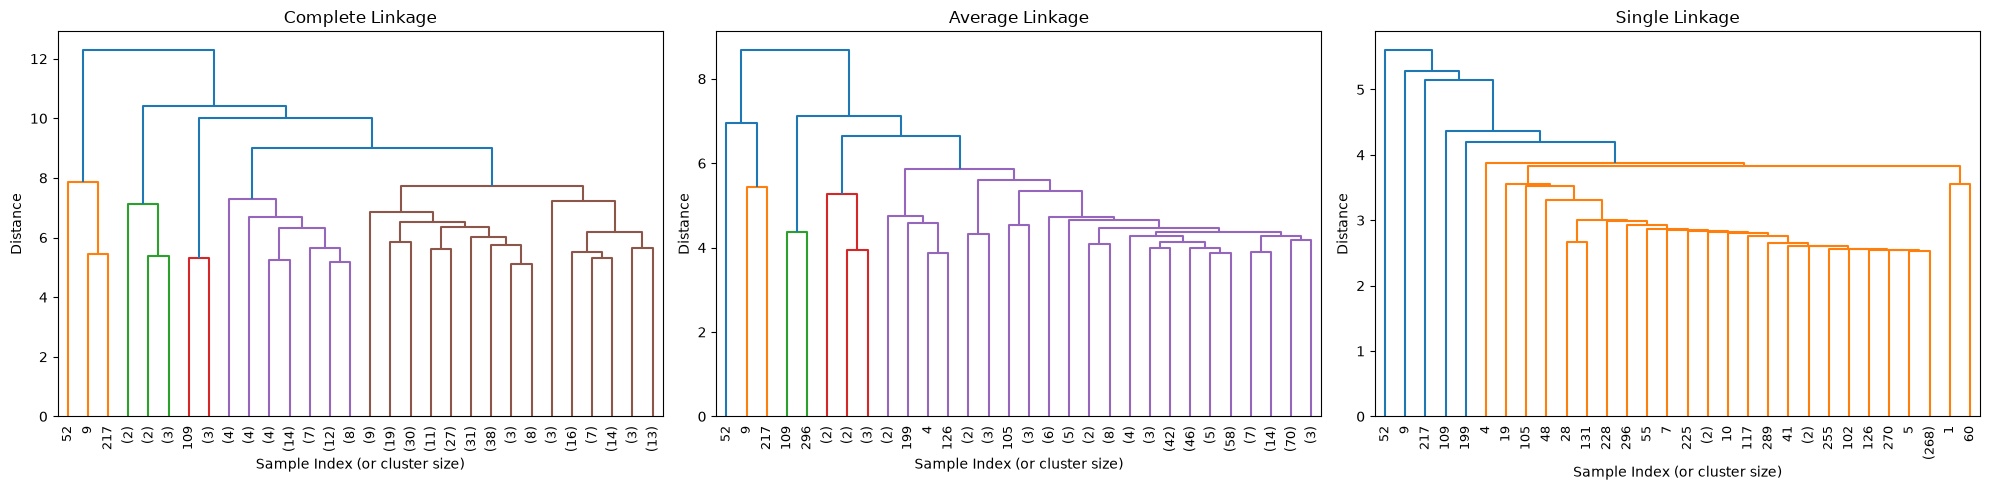

Ward: Balanced, compact clusters (minimizes variance)
Complete: Tend to produce compact clusters, sensitive to outliers
Average: Compromise between single and complete
Single: Can produce elongated 'chaining' clusters


In [28]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, method in zip(axes, ['complete', 'average', 'single']):
    Z_method = linkage(df_features_normalized, method=method)
    dendrogram(Z_method, truncate_mode='lastp', p=30,
               leaf_rotation=90, leaf_font_size=9, ax=ax)
    ax.set_title(f'{method.capitalize()} Linkage')
    ax.set_xlabel('Sample Index (or cluster size)')
    ax.set_ylabel('Distance')

plt.tight_layout()
plt.show()

print("Ward: Balanced, compact clusters (minimizes variance)")
print("Complete: Tend to produce compact clusters, sensitive to outliers")
print("Average: Compromise between single and complete")
print("Single: Can produce elongated 'chaining' clusters")

## Exercise: Compare confusion matrices of K-Means and Hierarchical Clustering to see which better recovers the true survived/died groups

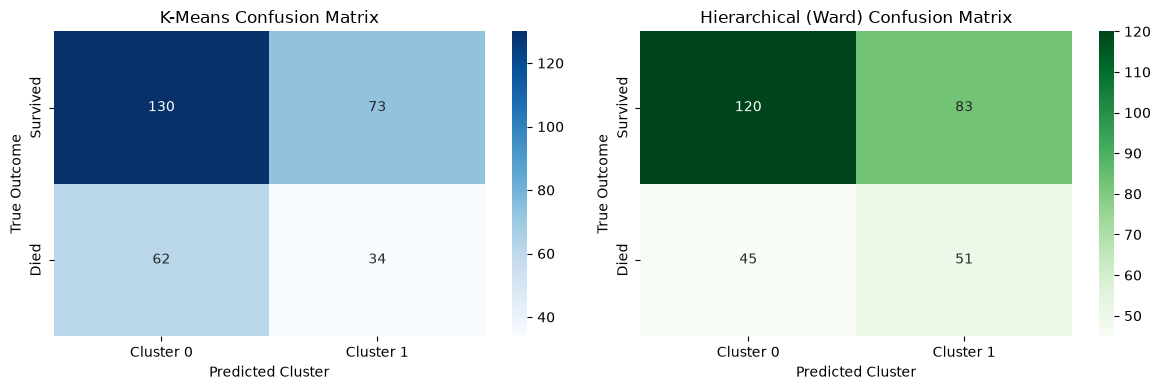

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm_km = confusion_matrix(df_target, clusters)
sns.heatmap(cm_km, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Cluster 0', 'Cluster 1'],
            yticklabels=['Survived', 'Died'])
axes[0].set_xlabel('Predicted Cluster')
axes[0].set_ylabel('True Outcome')
axes[0].set_title('K-Means Confusion Matrix')

cm_hc = confusion_matrix(df_target, hc_labels)
sns.heatmap(cm_hc, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Cluster 0', 'Cluster 1'],
            yticklabels=['Survived', 'Died'])
axes[1].set_xlabel('Predicted Cluster')
axes[1].set_ylabel('True Outcome')
axes[1].set_title('Hierarchical (Ward) Confusion Matrix')

plt.tight_layout()
plt.show()

## Discussion: Why do K-Means and hierarchical clustering fail to cleanly separate the survived and died groups in this dataset?

## Exercise: Run the statistical analysis on normalized data in Week 2. Is there any difference?

In [30]:
from scipy.stats import ttest_ind

survived = df_target == 0
died = df_target == 1

results_norm = []
results_raw = []

for col in df_features_normalized.columns:
    t_stat_n, p_val_n = ttest_ind(df_features_normalized.loc[survived, col],
                                  df_features_normalized.loc[died, col], equal_var=False)
    t_stat_r, p_val_r = ttest_ind(df_features.loc[survived, col],
                                  df_features.loc[died, col], equal_var=False)
    results_norm.append({'Feature': col, 'P-Value (normalized)': p_val_n})
    results_raw.append({'Feature': col, 'P-Value (raw)': p_val_r})

comparison = pd.DataFrame(results_norm)
comparison['P-Value (raw)'] = [r['P-Value (raw)'] for r in results_raw]
comparison['Difference'] = abs(comparison['P-Value (normalized)'] - comparison['P-Value (raw)'])
comparison = comparison.sort_values('P-Value (normalized)')

print(comparison.to_string(index=False))
print("\nThe p-values are IDENTICAL")
print("Z-scoring is a linear transformation (subtract mean, divide by std)")
print("So it does not change the t-statistic because both numerator and denominator scale by the same factor")

                 Feature  P-Value (normalized)  P-Value (raw)   Difference
       ejection_fraction              0.000010       0.000010 0.000000e+00
                     age              0.000047       0.000047 9.215718e-19
        serum_creatinine              0.000064       0.000064 3.523657e-19
            serum_sodium              0.001872       0.001872 5.095750e-17
     high_blood_pressure              0.179564       0.179564 5.551115e-17
                 anaemia              0.257064       0.257064 3.885781e-16
creatinine_phosphokinase              0.369216       0.369216 5.551115e-17
               platelets              0.399323       0.399323 8.881784e-16
                 smoking              0.827535       0.827535 1.110223e-16
                     sex              0.940901       0.940901 6.661338e-16
                diabetes              0.973345       0.973345 3.330669e-16

The p-values are IDENTICAL
Z-scoring is a linear transformation (subtract mean, divide by std)
So i

# Summary

Key Takeaways from Week 3:

1. Data Normalization: Z-score standardization is essential before PCA and clustering so that high-variance features (e.g., platelets, creatinine_phosphokinase) don't dominate.
2. PCA: Reduces dimensionality while preserving variance. Cumulative explained variance plots help decide how many components to keep.
3. K-Means: Partitions data into K spherical clusters. Requires choosing K in advance using the elbow method (inertia) or silhouette scores.
4. Hierarchical Clustering: Bottom-up approach that produces a dendrogram. No need to pick K upfront (cut the tree at different heights to explore different groupings). Linkage method choice affects cluster shape.
5. K-Means vs Hierarchical: K-Means is fast but requires K upfront and is sensitive to initialization. Hierarchical is deterministic and gives a full tree of merge history but is slower on large datasets.
6. Confusion Matrix: Useful for comparing unsupervised clusters against known labels, even though clustering is unsupervised

Next Steps: Supervised learning (using labeled data to build predictive models)

# Resources

Data Normalization:
- [Scikit-learn Preprocessing](https://scikit-learn.org/stable/modules/preprocessing.html)
- [Z-score vs Min-Max Scaling](https://www.analyticsvidhya.com/blog/2020/04/feature-scaling-machine-learning-normalization-standardization/)

PCA:
- [Scikit-learn PCA Documentation](https://scikit-learn.org/stable/modules/decomposition.html#pca)
- [StatQuest: PCA Explained](https://www.youtube.com/watch?v=FgakZw6K1QQ)

K-Means:
- [Scikit-learn KMeans](https://scikit-learn.org/stable/modules/clustering.html#k-means)
- [Elbow Method Explained](https://www.geeksforgeeks.org/elbow-method-for-optimal-value-of-k-in-kmeans/)
- [Silhouette Score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html)

Hierarchical Clustering:
- [Scikit-learn Agglomerative Clustering](https://scikit-learn.org/stable/modules/clustering.html#hierarchical-clustering)
- [Scipy Dendrogram](https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.dendrogram.html)
- [StatQuest: Hierarchical Clustering](https://www.youtube.com/watch?v=7xHsRkOdVwo)

Confusion Matrix:
- [Scikit-learn Confusion Matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html)